# Realistic DLI Mirror

This notebook is a **direct structural mirror** of
`old_demos/paper_demos/example_1.ipynb`, adapted to Deterministic Linear
Inference (DLI) rather than Bayesian inversion, and reduced to
$N_d = 50$ data and $N_p = 2$ property points.

## Structural correspondence with `example_1.ipynb`

| Aspect | `example_1.ipynb` | This notebook |
|---|---|---|
| Model space | `HilbertSpaceDirectSum([M_vp, M_vs, M_rho, M_σ₀, M_σ₁])` | **same block structure**, but functional subspaces are basis-free (`dim=0`, `basis=None`) |
| Forward kernels | Real seismic sensitivity kernels via `SensitivityKernelCatalog` | **same** — requires `kernels_modeplotaat_Adrian` |
| Property targets | Bump functions on M_vp, NullFunctionProvider on M_vs/M_rho | **same** |
| True model | Basis-backed coefficient vectors | Explicit callable series on basis-free spaces (same seeds, reduced-scale intent) |
| Data set | `GaussianMeasure(μ=d̃, C_D)` | Chi-squared deterministic ellipsoid `V` |
| Model prior | `GaussianMeasure` + `BesselSobolevInverse` | Covariance-matched 0.95 confidence ellipsoid $\mathcal{E}$ using block operators only |
| N_d / N_p | 140 / 20 | **50 / 2** |

**Kernel catalog is required.** If `kernels_modeplotaat_Adrian` is not found,
this notebook raises a `FileNotFoundError` rather than silently substituting
synthetic proxies. Provide the path via the environment variable
`INTERVALINF_KERNEL_CATALOG_DIR` or ensure the directory is present at a
standard candidate path.

## Mathematical Setup

We characterise the admissible property set
$$
\mathcal{U} = \mathcal{T}\!\left(\mathcal{E} \cap G^{-1}(\tilde{d} - \mathcal{V})\right)
$$
where:
- $\mathcal{E} = \bigl\{m : \langle C_0^{-1} m, m\rangle_{\mathcal{M}} \leq \chi^2_{d_{\rm eff}}(0.95)\bigr\}$ :
  the 0.95 confidence ellipsoid of the block-diagonal prior covariance $C_0$,
  where $d_{\rm eff}$ is the KL-truncation effective degrees of freedom.
- $\mathcal{V} = \{\eta \in \mathbb{R}^{N_d} : \eta^T C_D^{-1} \eta \leq \chi^2_{N_d}(0.95)\}$ :
  a deterministic ellipsoid defined by the 0.95-quantile of the chi-squared distribution.
  Under the Gaussian noise model $\eta \sim \mathcal{N}(0, C_D)$, exactly 95 % of noise
  realisations fall inside $\mathcal{V}$. The resulting property bounds are
  **worst-case-over-$\mathcal{V}$** bounds, not marginal confidence intervals.

For each property direction $q \in \mathcal{P}$, the support function is evaluated by
minimising the dual master cost function over $\lambda \in \mathcal{D}$:
$$
h_{\mathcal{U}}(q) = \inf_{\lambda \in \mathcal{D}} \left\{
    \langle \lambda, \tilde{d} \rangle_{\mathcal{D}}
    + \sigma_{\mathcal{E}}(T^* q - G^* \lambda)
    + \sigma_{\mathcal{V}}(-\lambda)
\right\},
$$


In [1]:
import sys
import os

# ---- Locate kernel_utils (paper_demos companion module) --------------------
_notebook_dir = os.getcwd()
_paper_demos_dir = os.path.normpath(
    os.path.join(_notebook_dir, '..', 'old_demos', 'paper_demos')
)
if _paper_demos_dir not in sys.path:
    sys.path.insert(0, _paper_demos_dir)

from kernel_utils import (
    SensitivityKernelCatalog,
    SensitivityKernelProvider,
    DepthCoordinateSystem,
    EARTH_RADIUS_KM,
)

# ---- intervalinf -----------------------------------------------------------
from intervalinf import (
    IntervalDomain, Lebesgue, LebesgueSpaceDirectSum, Function,
    IntegrationConfig, ParallelConfig, LebesgueIntegrationConfig,
    KnownRegion, PartitionedLebesgueSpace,
    BoundaryConditions,
)
from intervalinf.providers import (
    NormalModesProvider, BumpFunctionProvider, NullFunctionProvider,
)
from intervalinf.operators import (
    SOLAOperator, Laplacian, BesselSobolev, BesselSobolevInverse,
)
from intervalinf.sampling import KLSampler

# ---- pygeoinf --------------------------------------------------------------
from pygeoinf import (
    EuclideanSpace,
    LinearOperator,
    RowLinearOperator,
    HilbertSpaceDirectSum,
    EllipsoidSupportFunction,
    DenseMatrixLinearOperator
)
from pygeoinf.direct_sum import BlockDiagonalLinearOperator
from pygeoinf.backus_gilbert import DualMasterCostFunction
from pygeoinf.convex_optimisation import (
    ProximalBundleMethod,
    solve_support_values,
    OSQPQPSolver,
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2 as scipy_chi2
import time

figures_folder = 'realistic_dli_figures'

os.makedirs(figures_folder, exist_ok=True)

print('Imports OK')
print(f'  kernel_utils search path: {_paper_demos_dir}')


Imports OK
  kernel_utils search path: /home/adrian/PhD/Inferences/intervalinf/demos/old_demos/paper_demos


## Integration and Parallelisation Configuration

We use small integration grids; N_d = 50 and N_p = 2 keep the problem tractable.

In [2]:
Lebesgue_integration_cfg = LebesgueIntegrationConfig(
    inner_product=IntegrationConfig(method='trapz', n_points=512),
    dual=IntegrationConfig(method='trapz', n_points=512),
    general=IntegrationConfig(method='trapz', n_points=512),
)

sola_integration_cfg = IntegrationConfig(method='trapz', n_points=1024)

parallel_cfg = ParallelConfig(enabled=True, n_jobs=4)

print(f'SOLA integration: {sola_integration_cfg.method}, {sola_integration_cfg.n_points} points')
print(f'Parallel: {parallel_cfg.enabled}, n_jobs={parallel_cfg.n_jobs}')

SOLA integration: trapz, 1024 points
Parallel: True, n_jobs=4


## Kernel Catalog Locator

This notebook requires the external seismic sensitivity kernel catalog
(`kernels_modeplotaat_Adrian`).  The cell below locates it — or raises a
`FileNotFoundError` that explains exactly how to unblock execution.

Set `USE_SYNTHETIC_FALLBACK = True` **only** for exploratory / offline work.
The fallback is clearly labelled and must never be treated as the primary path.

In [3]:

# ===========================================================================
# KERNEL CATALOG LOCATOR
# The realistic DLI mirror requires the external seismic sensitivity kernel
# catalog (kernels_modeplotaat_Adrian).  Set USE_SYNTHETIC_FALLBACK = True
# ONLY for offline / exploratory work — the fallback is not the primary path.
# ===========================================================================

USE_SYNTHETIC_FALLBACK = False  # default: enforce realistic mirror

_catalog_env = os.environ.get('INTERVALINF_KERNEL_CATALOG_DIR', None)

_candidate_paths = [
    _catalog_env,
    # Correct location: old_demos/kernels_modeplotaat_Adrian
    os.path.join(_notebook_dir, '..', 'old_demos', 'kernels_modeplotaat_Adrian'),
    os.path.join(_notebook_dir, '..', 'kernels_modeplotaat_Adrian'),
    os.path.join(_notebook_dir, '..', '..', 'kernels_modeplotaat_Adrian'),
    os.path.join(_notebook_dir, '..', 'old_demos', 'paper_demos', 'kernels_modeplotaat_Adrian'),
    '/home/adrian/PhD/kernels_modeplotaat_Adrian',
    '/data/kernels_modeplotaat_Adrian',
]

catalog_path = None
for _p in _candidate_paths:
    if _p is not None and os.path.isdir(_p):
        catalog_path = os.path.normpath(_p)
        break

if catalog_path is None and not USE_SYNTHETIC_FALLBACK:
    _checked = '\n'.join(f'    - {p}' for p in _candidate_paths if p is not None)
    raise FileNotFoundError(
        "\n"
        "=======================================================================\n"
        "  REALISTIC DLI MIRROR: MISSING EXTERNAL KERNEL CATALOG\n"
        "=======================================================================\n"
        "  This notebook mirrors old_demos/paper_demos/example_1.ipynb and\n"
        "  requires the seismic sensitivity kernel catalog\n"
        "  'kernels_modeplotaat_Adrian' to proceed.\n"
        "\n"
        "  The catalog was NOT found at any of the following candidate paths:\n"
        f"{_checked}\n"
        "\n"
        "  To unblock execution:\n"
        "    1. Set the environment variable:\n"
        "         INTERVALINF_KERNEL_CATALOG_DIR=/path/to/kernels_modeplotaat_Adrian\n"
        "    2. Or place the catalog directory at one of the paths listed above.\n"
        "\n"
        "  To run the (non-primary) synthetic fallback instead:\n"
        "    Set USE_SYNTHETIC_FALLBACK = True in this cell.\n"
        "    Results in that mode are illustrative only.\n"
        "======================================================================="
    )
elif catalog_path is None and USE_SYNTHETIC_FALLBACK:
    print("=" * 68)
    print("  WARNING — SYNTHETIC FALLBACK ACTIVE")
    print("  Kernel catalog not found.  NormalModesProvider will be used.")
    print("  This is NOT the realistic mirror.  Results are illustrative only.")
    print("=" * 68)
else:
    print(f"Kernel catalog located at: {catalog_path}")


Kernel catalog located at: /home/adrian/PhD/Inferences/intervalinf/demos/old_demos/kernels_modeplotaat_Adrian


## Spaces

Mirrors the model-space decomposition from `example_1.ipynb`.

The full model space is the direct sum
$$
\mathcal{M} = \mathcal{M}_{vp} \oplus \mathcal{M}_{vs} \oplus \mathcal{M}_{\rho}
              \oplus \mathcal{M}_{\sigma_0} \oplus \mathcal{M}_{\sigma_1}
$$
where:
- $\mathcal{M}_{vp}, \mathcal{M}_{\rho}$: basis-free $L^2([0, R_\oplus])$ spaces (`dim=0`, `basis=None`)
- $\mathcal{M}_{vs}$ : **partitioned** (zero in outer core ICB–CMB) as
  $L^2([0, r_{ICB}]) \oplus L^2([r_{CMB}, R_\oplus])$, also basis-free
- $\mathcal{M}_{\sigma_0}, \mathcal{M}_{\sigma_1}$: $\mathbb{R}^1$ (ICB/CMB
  topography parameters)

A small helper truncation count `N=10` is still used for spectral operator setup,
KL truncation, and synthetic-series construction, but **not** as the dimension of
the functional model spaces.

**Note (DLI audit finding — Phase 4)**

The DLI result at `N_d = 50` is **prior-dominated** (posterior ≈ prior; λ* ≈ 0 for all property directions).

**Effective constraint window**: only the first ~15 catalog modes carry useful information for the bump-function property targets used here. The collapse is due to:

1. **Geometric dead-zone (property p0)**: all catalog modes have near-zero cosine similarity with the p0 bump target (cos ≈ 0 for all modes k=0..29).
2. **Geometric effect (property p1)**: the transition to prior-dominated is unchanged under 10× tighter noise (σ_d = 0.01 vs 0.10), confirming the collapse is geometric rather than SNR-driven.

The **results are still valid** — the posterior simply recovers the prior at this noise level and N_d configuration. Use `N_d ≤ 10` to observe data-constraining behaviour for these property targets and σ_d settings.

In [4]:
# Earth-domain boundaries (matches example_1.ipynb convention)
function_domain = IntervalDomain(0, EARTH_RADIUS_KM)
ICB_RADIUS = 1217.5   # km  (depth 5153.5 → radius 6371 - 5153.5)
CMB_RADIUS = 3480.0   # km  (depth 2891  → radius 6371 - 2891)

N = 10   # spectral helper / KL truncation count (not model-space dimension)
N_d = 50  # number of data points
N_p = 2  # number of property points

# ---- Heteroscedastic diagonal noise model (fixed, independent of signal) --
# Noise is specified per datum in km/s so it does NOT depend on signal amplitude.
# sigma_d[i] is the 1-σ standard deviation for the i-th measurement.
sigma_d_base   = 0.10   # km/s  — baseline noise floor (lowest-noise datum)
sigma_d_spread = 2.0    # ratio — max/min σ_d across the N_d data
sigma_d = sigma_d_base * np.linspace(1.0, sigma_d_spread, N_d)  # shape (N_d,)

# ---- Vp model space -------------------------------------------------------
M_vp = Lebesgue(0, function_domain, basis=None,
                integration_config=Lebesgue_integration_cfg,
                parallel_config=parallel_cfg)

# ---- Vs model space (partitioned: zero in outer core) ---------------------
outer_core_interval = IntervalDomain(ICB_RADIUS, CMB_RADIUS)
outer_core = KnownRegion.zero(outer_core_interval)

partitioned_vs = PartitionedLebesgueSpace(
    full_domain=function_domain,
    known_regions=[outer_core],
    dims=[0, 0],                         # [inner_core, mantle] are basis-free
    bases=[None, None],
    integration_config=Lebesgue_integration_cfg.inner_product,
    parallel_config=parallel_cfg,
 )
M_vs = partitioned_vs.model_space
M_vs_IC = partitioned_vs.unknown_spaces[0]   # [0, ICB]
M_vs_M  = partitioned_vs.unknown_spaces[1]   # [CMB, R_oplus]

# ---- Rho model space ------------------------------------------------------
M_rho = Lebesgue(0, function_domain, basis=None,
                 integration_config=Lebesgue_integration_cfg,
                 parallel_config=parallel_cfg)

# ---- Discontinuity parameter spaces (scalar EuclideanSpace) ---------------
M_sigma_0 = EuclideanSpace(1)   # ICB topography
M_sigma_1 = EuclideanSpace(1)   # CMB topography

# ---- Full model space (direct sum) ----------------------------------------
M_functions = LebesgueSpaceDirectSum([M_vp, M_vs, M_rho])
M_euclidean = HilbertSpaceDirectSum([M_sigma_0, M_sigma_1])
M_model     = HilbertSpaceDirectSum([M_functions, M_euclidean])

# ---- Data / property spaces -----------------------------------------------
D = EuclideanSpace(N_d)
P = EuclideanSpace(N_p)

x = function_domain.uniform_mesh(1000)    # visualisation grid

print(f'Domain                  : [0, {EARTH_RADIUS_KM}] km')
print(f'ICB / CMB radii         : {ICB_RADIUS} / {CMB_RADIUS} km')
print(f'Spectral helper count N : {N}')
print(f'M_vp dim                : {M_vp.dim}')
print(f'M_vs_IC dim             : {M_vs_IC.dim}   domain: {M_vs_IC.function_domain}')
print(f'M_vs_M  dim             : {M_vs_M.dim}   domain: {M_vs_M.function_domain}')
print(f'M_rho dim               : {M_rho.dim}')
print(f'M_sigma_0/1 dim         : 1 / 1')
print(f'M_functions dim         : {M_functions.dim}')
print(f'M_model dim             : {M_model.dim}')
print(f'Data space dim          : {N_d}')
print(f'Property dim            : {N_p}')
print(f'Noise model             : heteroscedastic diagonal  σ_d ∈ [{sigma_d.min():.3f}, {sigma_d.max():.3f}] km/s')


Domain                  : [0, 6371.0] km
ICB / CMB radii         : 1217.5 / 3480.0 km
Spectral helper count N : 10
M_vp dim                : 0
M_vs_IC dim             : 0   domain: [0.0, 1217.5]
M_vs_M  dim             : 0   domain: [3480.0, 6371.0]
M_rho dim               : 0
M_sigma_0/1 dim         : 1 / 1
M_functions dim         : 0
M_model dim             : 2
Data space dim          : 50
Property dim            : 2
Noise model             : heteroscedastic diagonal  σ_d ∈ [0.100, 0.200] km/s


## Forward and Property Operators

Mirrors `example_1.ipynb`'s operator construction exactly:

**Forward operator** $G : \mathcal{M} \to \mathbb{R}^{N_d}$

Real seismic sensitivity kernels are loaded from the catalog via
`SensitivityKernelProvider` (one provider per component: vp, vs_IC, vs_M, rho).
Discontinuity sensitivities $K_{\sigma_0}$, $K_{\sigma_1}$ are extracted from
the topo-kernel entries at the ICB and CMB depths.  The full forward operator is
assembled as a `RowLinearOperator`.

**Property operator** $T : \mathcal{M} \to \mathbb{R}^{N_p}$

Bump-function targets centred at $N_p$ radii on $M_{vp}$.  All other
components ($M_{vs}$, $M_\rho$, $M_{\sigma}$) map to zero via
`NullFunctionProvider` / zero `LinearOperator`, matching example_1.ipynb.

In [5]:
if USE_SYNTHETIC_FALLBACK:
    # -----------------------------------------------------------------------
    # [SYNTHETIC FALLBACK — NOT THE PRIMARY PATH]
    # Replaces kernel catalog with NormalModesProvider proxies.
    # For exploratory use only when the real kernel catalog is unavailable.
    # -----------------------------------------------------------------------
    normal_modes_provider_vp = NormalModesProvider(
        M_vp, n_modes_range=(2, 6), coeff_range=(-3.0, 3.0),
        gaussian_width_percent_range=(5, 20), freq_range=(0.1, 5.0), random_state=7,
    )
    G_vp  = SOLAOperator(M_vp,    D, kernels=normal_modes_provider_vp,
                         cache_kernels=True, integration_config=sola_integration_cfg)
    G_vs_IC = SOLAOperator(M_vs_IC, D, kernels=NullFunctionProvider(M_vs_IC),
                           cache_kernels=True, integration_config=sola_integration_cfg)
    G_vs_M  = SOLAOperator(M_vs_M,  D, kernels=NullFunctionProvider(M_vs_M),
                           cache_kernels=True, integration_config=sola_integration_cfg)
    G_rho   = SOLAOperator(M_rho,   D, kernels=NullFunctionProvider(M_rho),
                           cache_kernels=True, integration_config=sola_integration_cfg)
    K_sigma_0_vals = np.zeros(N_d)
    K_sigma_1_vals = np.zeros(N_d)
    print('[SYNTHETIC FALLBACK] Forward operators created with NormalModesProvider for vp.')

else:
    # -----------------------------------------------------------------------
    # PRIMARY PATH — realistic kernel catalog
    # -----------------------------------------------------------------------
    from pathlib import Path
    catalog = SensitivityKernelCatalog(Path(catalog_path))
    mode_ids = catalog.list_modes()[:N_d]
    print(f'Loaded catalog: {N_d} modes selected from {len(catalog.list_modes())} available')

    # Volume-kernel providers (vp, vs, rho)
    vp_kernel_provider = SensitivityKernelProvider(
        M_vp, catalog, interpolation_method='cubic',
        include_discontinuities=True, kernel_type='vp',
    )
    rho_kernel_provider = SensitivityKernelProvider(
        M_rho, catalog, interpolation_method='cubic',
        include_discontinuities=True, kernel_type='rho',
    )

    # Vs: full-domain provider then restrict to IC / mantle
    _vs_full_space = Lebesgue(N, function_domain, basis='none')
    vs_kernel_full_provider = SensitivityKernelProvider(
        _vs_full_space, catalog, interpolation_method='cubic',
        include_discontinuities=True, kernel_type='vs',
    )
    vs_kernel_IC_provider = vs_kernel_full_provider.restrict(M_vs_IC)
    vs_kernel_M_provider  = vs_kernel_full_provider.restrict(M_vs_M)

    # Topography sensitivities (ICB / CMB) — same pattern as example_1.ipynb
    icb_depth = 5153.5  # km from surface
    cmb_depth = 2891.0
    icb_vals, cmb_vals = [], []
    for mid in mode_ids:
        topo = vp_kernel_provider.get_topo_kernel(mid)
        icb_v = topo.get_value_at_depth(icb_depth, tolerance=100.0) if topo is not None else None
        cmb_v = topo.get_value_at_depth(cmb_depth, tolerance=100.0) if topo is not None else None
        icb_vals.append(icb_v if icb_v is not None else 0.0)
        cmb_vals.append(cmb_v if cmb_v is not None else 0.0)
    K_sigma_0_vals = np.array(icb_vals)
    K_sigma_1_vals = np.array(cmb_vals)

    # SOLA forward operators per component
    G_vp    = SOLAOperator(M_vp,    D, vp_kernel_provider,    integration_config=sola_integration_cfg)
    G_rho   = SOLAOperator(M_rho,   D, rho_kernel_provider,   integration_config=sola_integration_cfg)
    G_vs_IC = SOLAOperator(M_vs_IC, D, vs_kernel_IC_provider, integration_config=sola_integration_cfg)
    G_vs_M  = SOLAOperator(M_vs_M,  D, vs_kernel_M_provider,  integration_config=sola_integration_cfg)

    print(f'G_vp, G_rho, G_vs_IC, G_vs_M created from catalog.')

# ---- block assembly (common to both paths) --------------------------------
G_vs       = RowLinearOperator([G_vs_IC, G_vs_M])
G_sigma_0  = LinearOperator(M_sigma_0, D, lambda s: K_sigma_0_vals * s[0])
G_sigma_1  = LinearOperator(M_sigma_1, D, lambda s: K_sigma_1_vals * s[0])
G_functions = RowLinearOperator([G_vp, G_vs, G_rho])
G_euclidean = RowLinearOperator([G_sigma_0, G_sigma_1])
G = RowLinearOperator([G_functions, G_euclidean])

# ---- Property operator ----------------------------------------------------
width = 0.2 * EARTH_RADIUS_KM
centers = np.linspace(function_domain.a + width / 2,
                      function_domain.b - width / 2, N_p)

target_provider_vp    = BumpFunctionProvider(M_vp,    centers=centers, default_width=width)
target_provider_vs_IC = NullFunctionProvider(M_vs_IC)
target_provider_vs_M  = NullFunctionProvider(M_vs_M)
target_provider_rho   = NullFunctionProvider(M_rho)

T_vp    = SOLAOperator(M_vp,    P, target_provider_vp,    integration_config=sola_integration_cfg)
T_vs_IC = SOLAOperator(M_vs_IC, P, target_provider_vs_IC, integration_config=sola_integration_cfg)
T_vs_M  = SOLAOperator(M_vs_M,  P, target_provider_vs_M,  integration_config=sola_integration_cfg)
T_rho   = SOLAOperator(M_rho,   P, target_provider_rho,   integration_config=sola_integration_cfg)
T_sigma_0 = LinearOperator(M_sigma_0, P, lambda s: np.zeros(N_p))
T_sigma_1 = LinearOperator(M_sigma_1, P, lambda s: np.zeros(N_p))

T_vs        = RowLinearOperator([T_vs_IC, T_vs_M])
T_functions = RowLinearOperator([T_vp, T_vs, T_rho])
T_euclidean = RowLinearOperator([T_sigma_0, T_sigma_1])
T = RowLinearOperator([T_functions, T_euclidean])

print(f'\nForward operator G  : M_model → R^{N_d}')
print(f'Property operator T : M_model → R^{N_p}')
print(f'Property centres (km): {np.round(centers, 1)}')


Loaded catalog: 50 modes selected from 143 available
G_vp, G_rho, G_vs_IC, G_vs_M created from catalog.

Forward operator G  : M_model → R^50
Property operator T : M_model → R^2
Property centres (km): [ 637.1 5733.9]


## Kernels Visualisation

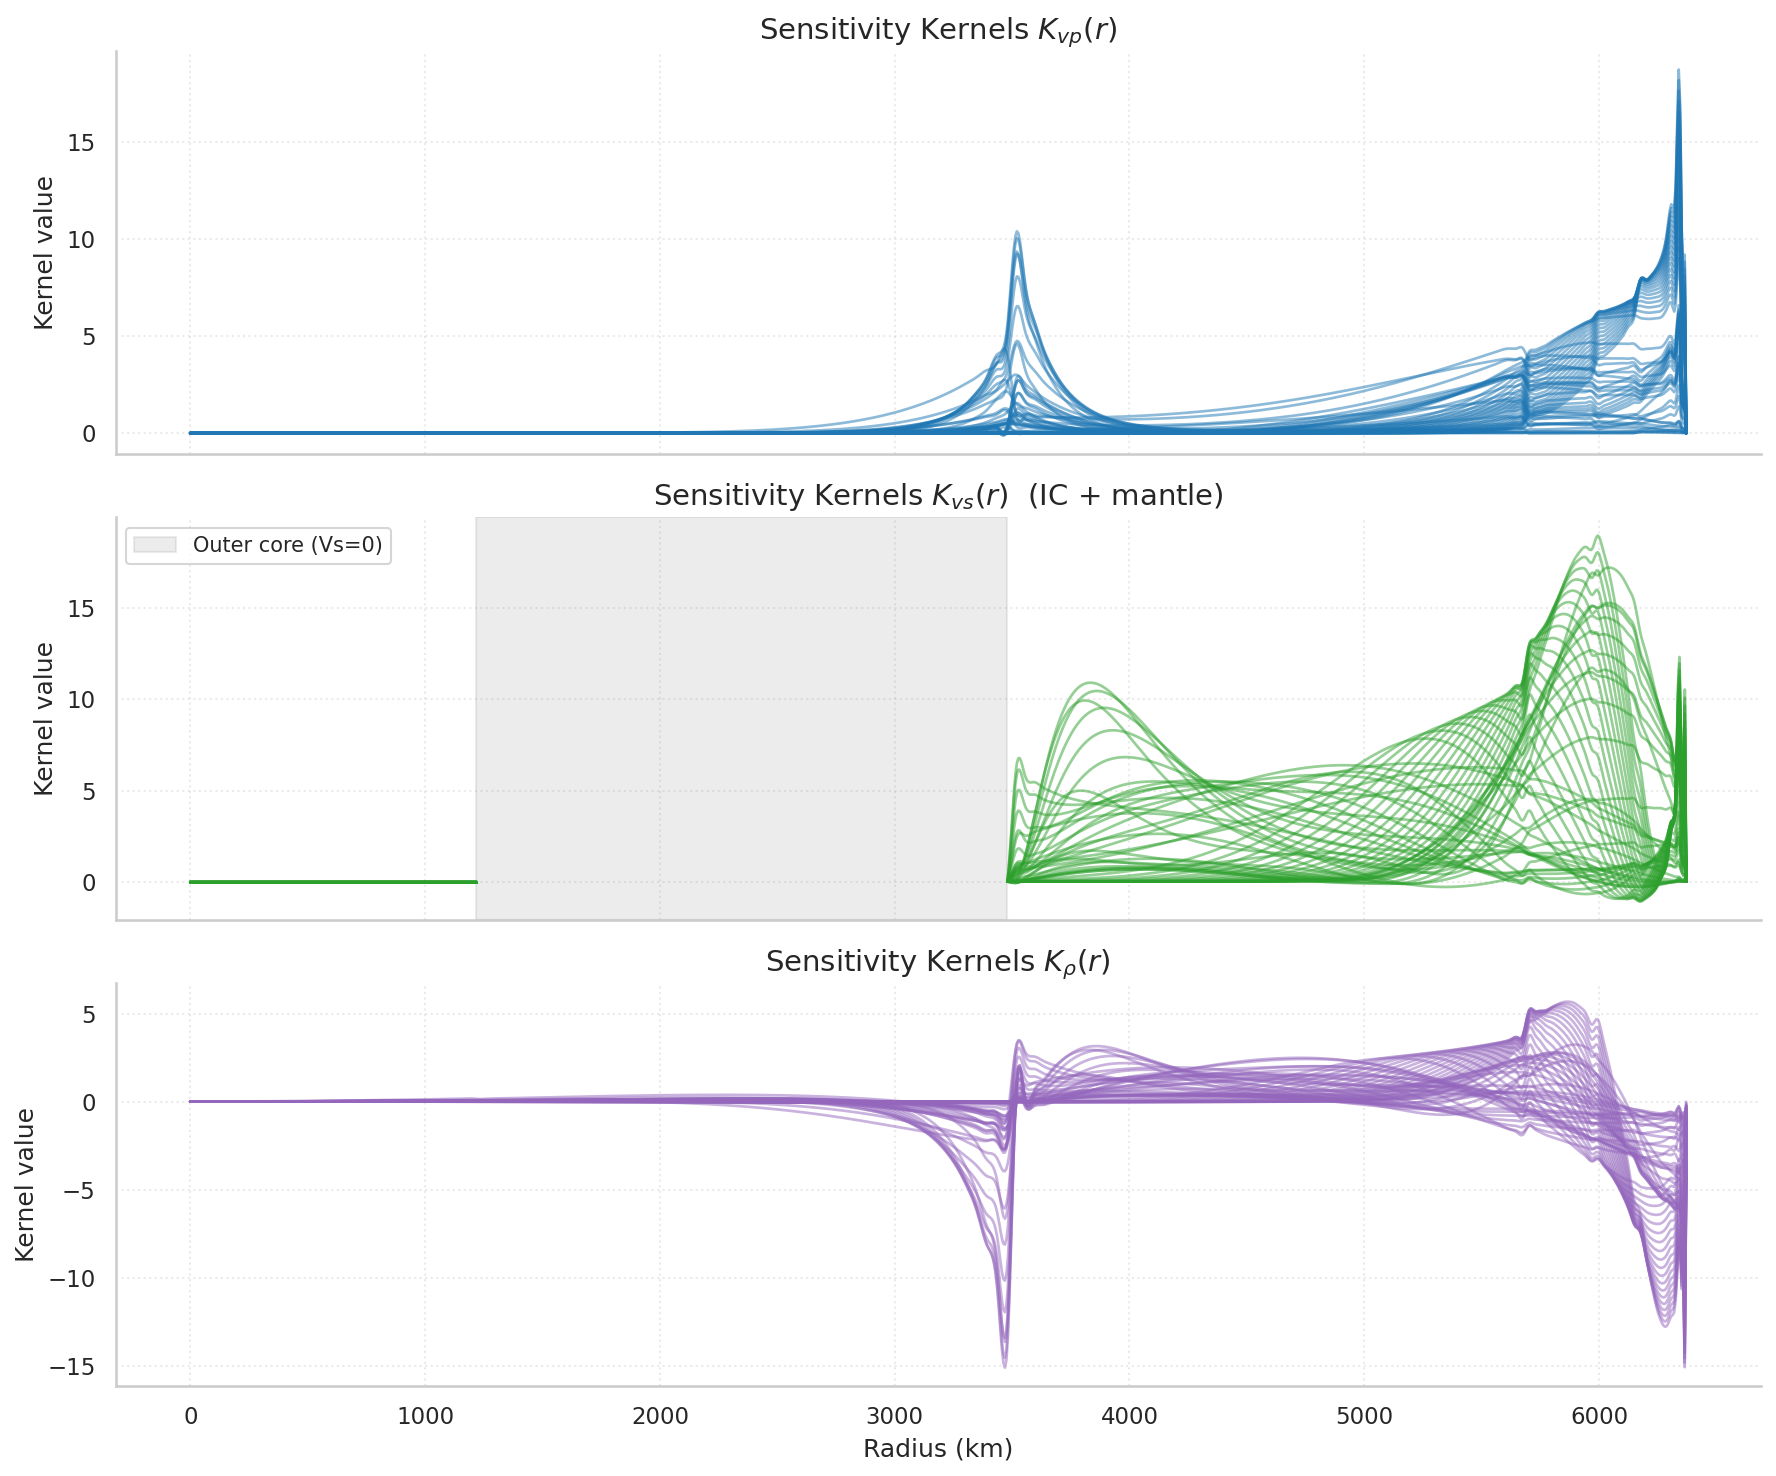

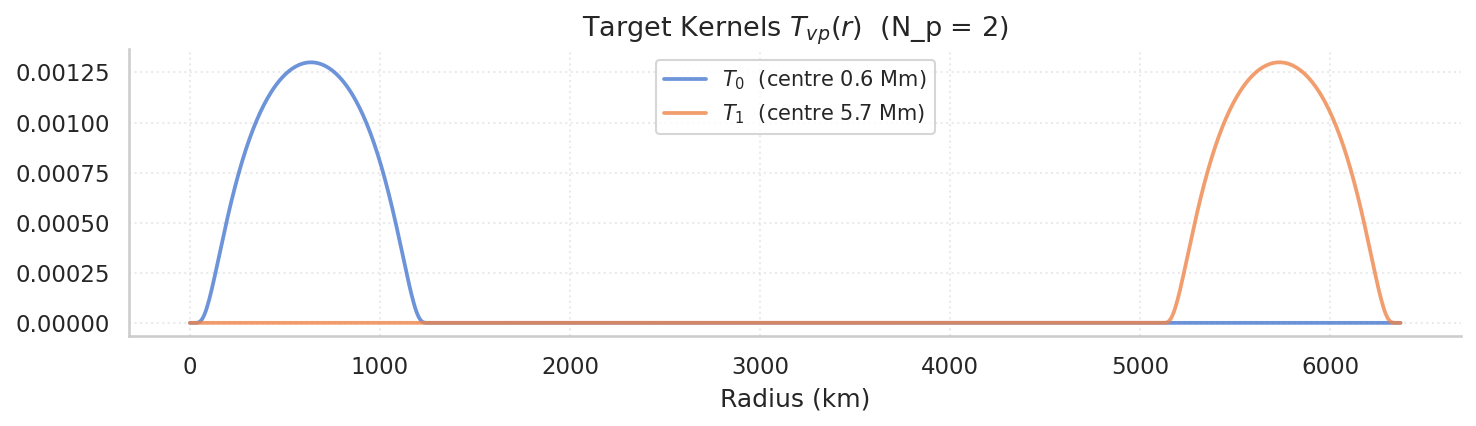

In [6]:
sns.set_theme(style='whitegrid', palette='muted')
x_IC = np.linspace(M_vs_IC.function_domain.a, M_vs_IC.function_domain.b, 500)
x_M  = np.linspace(M_vs_M.function_domain.a,  M_vs_M.function_domain.b,  500)

fig, axs = plt.subplots(3, 1, figsize=(12, 10), dpi=150, sharex=True)

# --- vp kernels ---
for i in range(N_d):
    axs[0].plot(x, G_vp.get_kernel(i).evaluate(x),
                color='tab:blue', alpha=0.5, linewidth=1.3)
axs[0].set_title(r'Sensitivity Kernels $K_{vp}(r)$', fontsize=14)
axs[0].set_ylabel('Kernel value', fontsize=12)
axs[0].grid(True, linestyle=':', alpha=0.4)

# --- vs kernels (IC + mantle; outer core shaded) ---
for i in range(N_d):
    axs[1].plot(x_IC, G_vs_IC.get_kernel(i).evaluate(x_IC),
                color='tab:green', alpha=0.5, linewidth=1.3)
    axs[1].plot(x_M,  G_vs_M.get_kernel(i).evaluate(x_M),
                color='tab:green', alpha=0.5, linewidth=1.3)
axs[1].axvspan(ICB_RADIUS, CMB_RADIUS, alpha=0.15, color='gray', label='Outer core (Vs=0)')
axs[1].set_title(r'Sensitivity Kernels $K_{vs}(r)$  (IC + mantle)', fontsize=14)
axs[1].set_ylabel('Kernel value', fontsize=12)
axs[1].legend(fontsize=10)
axs[1].grid(True, linestyle=':', alpha=0.4)

# --- rho kernels ---
for i in range(N_d):
    axs[2].plot(x, G_rho.get_kernel(i).evaluate(x),
                color='tab:purple', alpha=0.5, linewidth=1.3)
axs[2].set_title(r'Sensitivity Kernels $K_{\rho}(r)$', fontsize=14)
axs[2].set_xlabel('Radius (km)', fontsize=12)
axs[2].set_ylabel('Kernel value', fontsize=12)
axs[2].grid(True, linestyle=':', alpha=0.4)

# --- property targets (overlay on separate figure) ---
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 3), dpi=150)
for i in range(N_p):
    ax2.plot(x, T_vp.get_kernel(i).evaluate(x),
             alpha=0.8, linewidth=1.8,
             label=f'$T_{{{i}}}$  (centre {centers[i]/1e3:.1f} Mm)')
ax2.set_title(r'Target Kernels $T_{vp}(r)$  (N_p = ' + str(N_p) + ')', fontsize=13)
ax2.set_xlabel('Radius (km)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.4)

for fig_obj, name in [(fig, 'kernels_sensitivity'), (fig2, 'kernels_target')]:
    sns.despine(fig=fig_obj)
    fig_obj.tight_layout()
    fig_obj.savefig(os.path.join(figures_folder, f'{name}.png'), dpi=200, bbox_inches='tight')

plt.show()


## True Model and Synthetic Data

Mirrors `example_1.ipynb`'s per-component `ran_array` construction:
each function-space component gets a sparse 10-coefficient vector drawn from
`Uniform(-1, 1)` (same seeds as example_1).  Discontinuity parameters
$\sigma_0 = 1$, $\sigma_1 = 2$ are kept fixed as scalars.

The full block model is assembled as a nested list matching the
`M_model = HilbertSpaceDirectSum([M_functions, M_euclidean])` structure.

True property values: [ 0.01035 -0.00654]


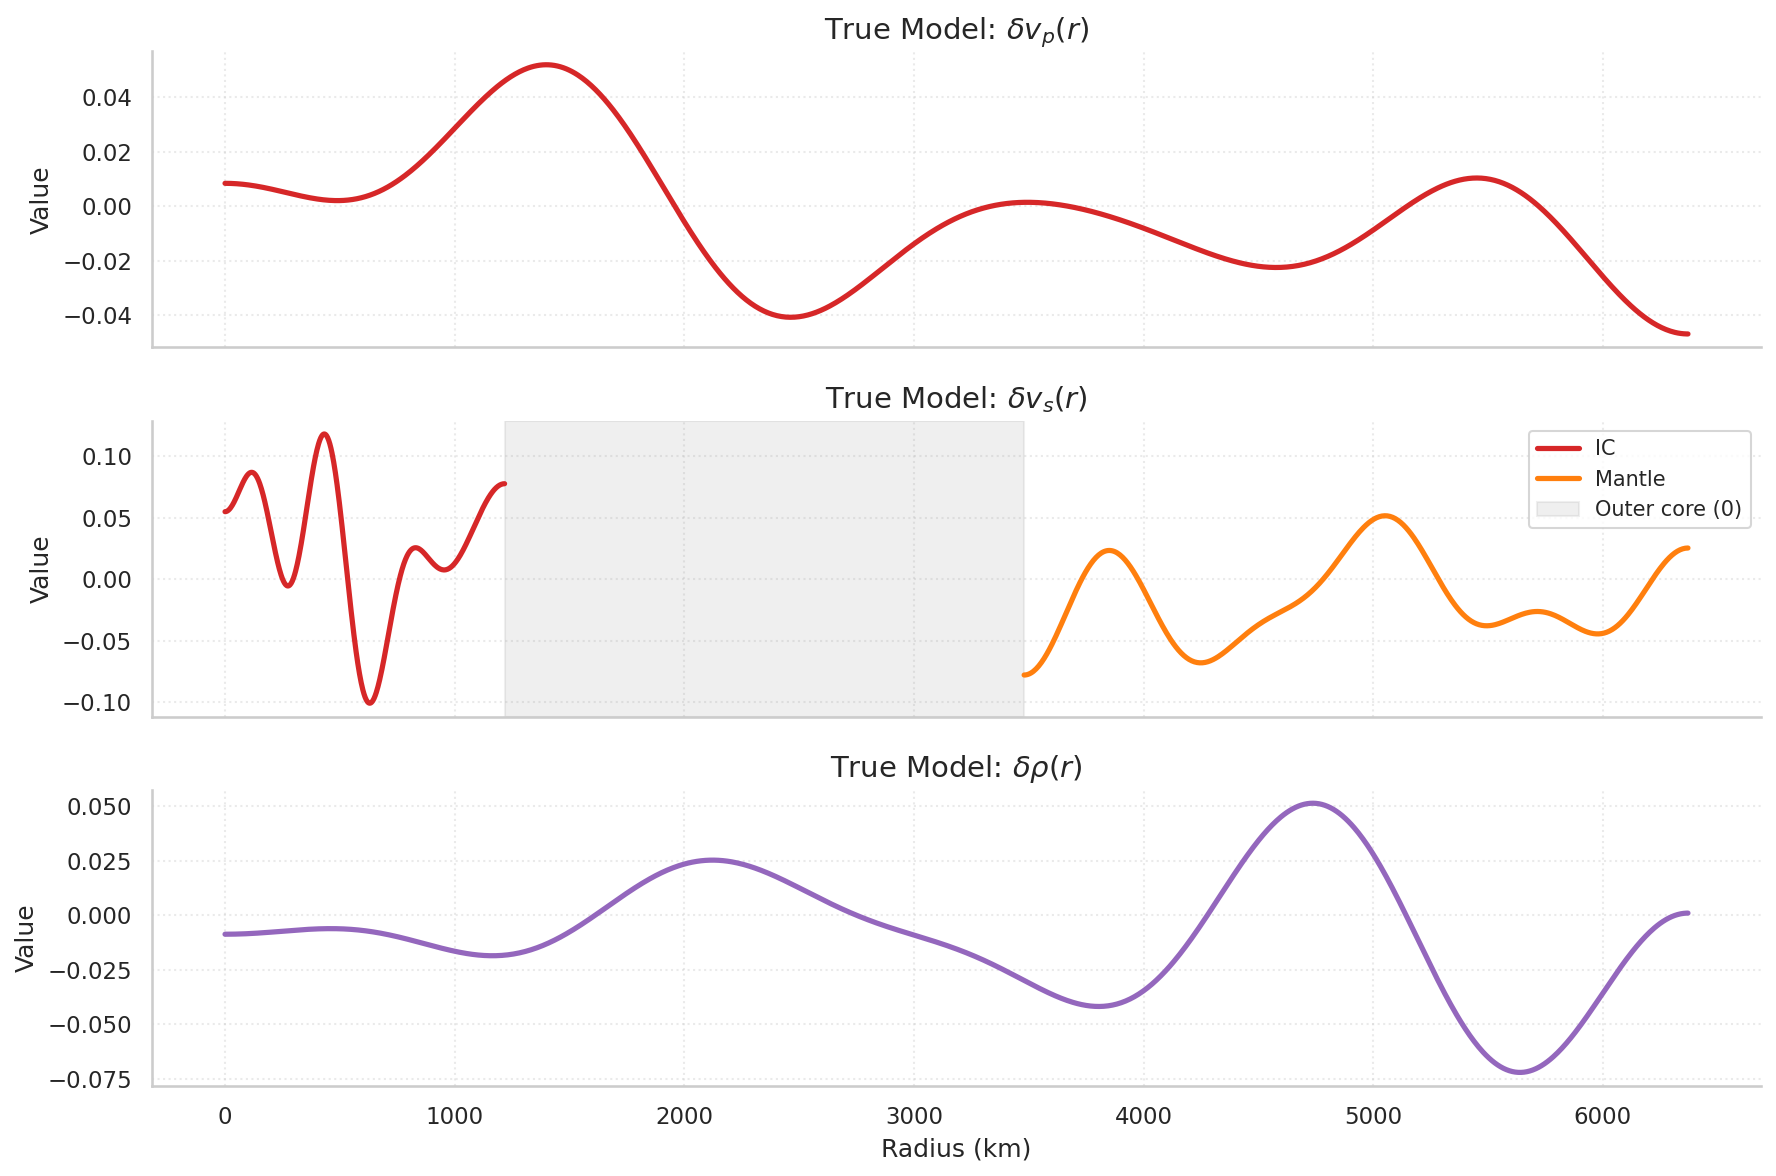

In [7]:
def cosine_series_function(space, coeffs):
    """Build a callable Function from an L2-normalised cosine series."""
    coeffs = np.asarray(coeffs, dtype=float)
    a = space.function_domain.a
    b = space.function_domain.b
    length = b - a

    def evaluate(x):
        x = np.asarray(x, dtype=float)
        xi = (x - a) / length
        values = np.zeros_like(xi, dtype=float)
        if coeffs.size > 0:
            values += coeffs[0] / np.sqrt(length)
        for k, ck in enumerate(coeffs[1:], start=1):
            values += ck * np.sqrt(2.0 / length) * np.cos(np.pi * k * xi)
        return values

    return Function(space, evaluate_callable=evaluate)

# --- per-component random coefficient arrays (same seeds as example_1.ipynb) ---
ran_array_vp = np.random.RandomState(42).uniform(-1.0, 1.0, N)
ran_array_vs_IC = np.random.RandomState(24).uniform(-1.0, 1.0, N)
ran_array_vs_M = np.random.RandomState(84).uniform(-1.0, 1.0, N)
ran_array_rho = np.random.RandomState(12).uniform(-1.0, 1.0, N)

# --- construct basis-free Function objects from explicit callable series ---
m_bar_vp    = cosine_series_function(M_vp, ran_array_vp)
m_bar_vs_IC = cosine_series_function(M_vs_IC, ran_array_vs_IC)
m_bar_vs_M  = cosine_series_function(M_vs_M, ran_array_vs_M)
m_bar_rho   = cosine_series_function(M_rho, ran_array_rho)

m_bar_sigma_0 = np.array([1.0])   # ICB discontinuity magnitude
m_bar_sigma_1 = np.array([2.0])   # CMB discontinuity magnitude

# --- assemble block model (nested lists matching RowLinearOperator structure) ---
m_bar = [
    [m_bar_vp, [m_bar_vs_IC, m_bar_vs_M], m_bar_rho],
    [m_bar_sigma_0, m_bar_sigma_1],
]

# --- true property values (only T_vp is non-null) ---
true_props = T(m_bar)
print(f'True property values: {np.round(true_props, 5)}')

# --- visualise true model components ---
x_IC_vis = np.linspace(M_vs_IC.function_domain.a, M_vs_IC.function_domain.b, 500)
x_M_vis  = np.linspace(M_vs_M.function_domain.a,  M_vs_M.function_domain.b,  500)

fig, axs = plt.subplots(3, 1, figsize=(12, 8), dpi=150, sharex=True)

axs[0].plot(x, m_bar_vp.evaluate(x),  color='tab:red', linewidth=2.5, label=r'$\bar{m}_{vp}$')
axs[0].set_title(r'True Model: $\delta v_p(r)$', fontsize=14)
axs[0].set_ylabel('Value', fontsize=12)
axs[0].grid(True, linestyle=':', alpha=0.4)

axs[1].plot(x_IC_vis, m_bar_vs_IC.evaluate(x_IC_vis), color='tab:red', linewidth=2.5,
            label='IC')
axs[1].plot(x_M_vis,  m_bar_vs_M.evaluate(x_M_vis),  color='tab:orange', linewidth=2.5,
            label='Mantle')
axs[1].axvspan(ICB_RADIUS, CMB_RADIUS, alpha=0.12, color='gray', label='Outer core (0)')
axs[1].set_title(r'True Model: $\delta v_s(r)$', fontsize=14)
axs[1].set_ylabel('Value', fontsize=12)
axs[1].legend(fontsize=10)
axs[1].grid(True, linestyle=':', alpha=0.4)

axs[2].plot(x, m_bar_rho.evaluate(x), color='tab:purple', linewidth=2.5, label=r'$\bar{m}_\rho$')
axs[2].set_title(r'True Model: $\delta\rho(r)$', fontsize=14)
axs[2].set_xlabel('Radius (km)', fontsize=12)
axs[2].set_ylabel('Value', fontsize=12)
axs[2].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'true_models.png'), dpi=200, bbox_inches='tight')
plt.show()


In [8]:
# Synthetic observations — heteroscedastic diagonal noise
# Noise is drawn per datum from the configured sigma_d vector (fixed, signal-independent).
print('Generating synthetic data...')
d_bar = G(m_bar)   # G: M_model → R^{N_d}  (numpy array, shape (N_d,))

np.random.seed(42)
noise_realisation = np.random.normal(0, sigma_d)   # per-datum std-dev σ_d[i]
d_tilde = d_bar + noise_realisation

print(f'  Noise model           : heteroscedastic diagonal (fixed σ_d per datum)')
print(f'  σ_d range             : [{sigma_d.min():.4f}, {sigma_d.max():.4f}] km/s')
print(f'  σ_d mean              : {sigma_d.mean():.4f} km/s')
print(f'  Signal peak |d_bar|   : {np.max(np.abs(d_bar)):.5f}')
print(f'  True data   d_bar   : {np.round(d_bar, 5)}')
print(f'  Noisy data  d_tilde : {np.round(d_tilde, 5)}')
print(f'  Noise       η       : {np.round(noise_realisation, 5)}')
print(f'  |η_i/σ_d_i| max     : {np.max(np.abs(noise_realisation / sigma_d)):.2f}  (expect O(1))')


Generating synthetic data...
  Noise model           : heteroscedastic diagonal (fixed σ_d per datum)
  σ_d range             : [0.1000, 0.2000] km/s
  σ_d mean              : 0.1500 km/s
  Signal peak |d_bar|   : 536.96513
  True data   d_bar   : [-189.9851  -188.29581 -170.39096 -143.28322 -106.37135  -61.74745
  -22.54576  -40.84793  -81.2278  -128.83152 -179.60461 -230.50894
 -279.32136 -324.51354 -365.15335 -400.79579 -431.36871 -457.05292
 -478.21092 -495.28373 -508.74009 -519.05352 -526.65923 -531.95429
 -535.2875  -536.96513 -113.59917 -105.60426  -66.73874  -22.7913
  -25.75457  -59.0266  -102.58881 -137.68235 -158.97171 -171.62177
 -184.68001 -217.26793 -296.91528 -326.81483 -180.73614 -207.79942
 -263.85084 -300.33825 -328.5747  -351.25197 -366.96455 -373.94429
 -370.0697  -351.04759]
  Noisy data  d_tilde : [-189.93542 -188.30992 -170.32355 -143.12159 -106.39667  -61.77326
  -22.3685   -40.76022  -81.28241 -128.7673  -179.6604  -230.56597
 -279.29124 -324.75563 -365.37512 -

## Data Error Set

We assume $\eta \sim \mathcal{N}(0, C_D)$ with $C_D = \mathrm{diag}(\sigma_d^2)$,
a heteroscedastic diagonal covariance in which each datum $i$ carries its own
measurement uncertainty $\sigma_{d,i}$ drawn from the configured `sigma_d` vector.

The corresponding deterministic error set is
$$
\mathcal{V} = \bigl\{\,\eta \in \mathbb{R}^{N_d} :\;\eta^T C_D^{-1} \eta \leq \chi^2_{N_d}(0.95)\bigr\}.
$$
Under the assumed Gaussian noise model, $\mathrm{P}(\eta \in \mathcal{V}) = 0.95$.
The DLI bounds are **worst-case over $\mathcal{V}$**: they hold for any noise
realisation inside the set, but they do not represent marginal
$1-\alpha$ confidence intervals for individual properties.

The support function of $\mathcal{V}$ evaluated at $\lambda$ is
$$
\sigma_{\mathcal{V}}(\lambda)
= \sqrt{\chi^2_{N_d}(0.95)}\,\bigl\|C_D^{1/2}\,\lambda\bigr\|,
$$
with $C_D^{1/2} = \mathrm{diag}(\sigma_d)$ and $C_D^{-1} = \mathrm{diag}(\sigma_d^{-2})$,
implemented via `EllipsoidSupportFunction`.

In [9]:
# ---- Data covariance — heteroscedastic diagonal C_D = diag(sigma_d**2) ----
C_D_matrix      = np.diag(sigma_d ** 2)           # shape (N_d, N_d)
C_D_inv_matrix  = np.diag(1.0 / sigma_d ** 2)     # C_D^{-1} = diag(sigma_d^{-2})
C_D_sqrt_matrix = np.diag(sigma_d)                # C_D^{1/2} = diag(sigma_d)

# Guard against singular / near-singular covariance
_eigs = np.linalg.eigvalsh(C_D_matrix)
if np.any(_eigs <= 0):
    raise ValueError(
        f'C_D is not positive definite: min eigenvalue = {_eigs.min():.3e}. '
        'Cannot form EllipsoidSupportFunction — check sigma_d.'
    )

# Chi-squared 0.95 radius
chi2_ppf_95 = scipy_chi2.ppf(0.95, df=N_d)   # χ²_{N_d}(0.95)
chi2_radius = float(np.sqrt(chi2_ppf_95))

A_op          = DenseMatrixLinearOperator(D, D, C_D_inv_matrix)
A_inv_op      = DenseMatrixLinearOperator(D, D, C_D_matrix)
A_inv_sqrt_op = DenseMatrixLinearOperator(D, D, C_D_sqrt_matrix)

data_error_support = EllipsoidSupportFunction(
    D,
    center=D.zero,
    radius=chi2_radius,
    shape_operator=A_op,
    inverse_operator=A_inv_op,
    inverse_sqrt_operator=A_inv_sqrt_op,
)

print(f'Noise model                  : heteroscedastic diagonal C_D = diag(σ_d²)')
print(f'σ_d range                    : [{sigma_d.min():.5f}, {sigma_d.max():.5f}] km/s')
print(f'σ_d mean                     : {sigma_d.mean():.5f} km/s')
print(f'min eigenvalue of C_D        = {_eigs.min():.3e}  (positive: OK)')
print(f'χ²(0.95, df={N_d})           = {chi2_ppf_95:.4f}')
print(f'Ellipsoid radius √χ²         = {chi2_radius:.4f}')

# Sanity: is the realised noise inside the 0.95 set?
mahal_sq = float(noise_realisation @ C_D_inv_matrix @ noise_realisation)
print(f'\nRealised noise ‖η‖²_{{C_D}}   = {mahal_sq:.4f}  (threshold {chi2_ppf_95:.4f})')
print(f'Inside V                     : {mahal_sq <= chi2_ppf_95}')
sf_at_zero = data_error_support(D.zero)
print(f'σ_V(0) (must be 0)           : {sf_at_zero:.6f}')


Noise model                  : heteroscedastic diagonal C_D = diag(σ_d²)
σ_d range                    : [0.10000, 0.20000] km/s
σ_d mean                     : 0.15000 km/s
min eigenvalue of C_D        = 1.000e-02  (positive: OK)
χ²(0.95, df=50)           = 67.5048
Ellipsoid radius √χ²         = 8.2161

Realised noise ‖η‖²_{C_D}   = 45.2571  (threshold 67.5048)
Inside V                     : True
σ_V(0) (must be 0)           : 0.000000


## Model Prior Set — Covariance-Matched Confidence Ellipsoid

The model prior is a **deterministic confidence ellipsoid** derived from the
same Gaussian covariance structure used in `example_1.ipynb`, but implemented
purely operator-theoretically on basis-free function spaces.

### Covariance model

Each functional component uses a Matérn-like `BesselSobolevInverse` covariance
$C_0 = (k^2 I - \alpha\Delta)^{-s}$ (with hyperparameters matching example_1):

| Component | $s$ | $L_{\rm corr}$ (km) | $\sigma^2$ |
|-----------|-----|---------------------|------------|
| $\delta v_p$ | 6 | 20 | 10 |
| $\delta v_s$ (IC, M) | 4 | 20 | 10 |
| $\delta\rho$ | 5 | 25 | 10 |
| $\sigma_0,\sigma_1$ | — | — | 10 |

### Confidence ellipsoid

The model prior set is the 95 % confidence ellipsoid of the block-diagonal
prior covariance $C_0$:
$$
\mathcal{E} = \bigl\{\,m :\;
  \langle C_0^{-1}\,m,\,m\rangle_{\mathcal{M}} \leq \chi^2_{d_{\rm eff}}(0.95)
\bigr\},
$$
where the **effective degrees of freedom** $d_{\rm eff}$ is determined by
**KL truncation**: counting KL modes whose eigenvalue exceeds $10^{-4}$ times
the leading eigenvalue (summed over all functional components, plus 2 for
$\sigma_0,\sigma_1$).

The support function of $\mathcal{E}$ at $v \in \mathcal{M}$ is
$$
\sigma_{\mathcal{E}}(v)
= \sqrt{\chi^2_{d_{\rm eff}}(0.95)}\;\bigl\|\,C_0^{1/2}\,v\,\bigr\|_{\mathcal{M}},
$$
implemented via `EllipsoidSupportFunction` using `BlockDiagonalLinearOperator`
composition only: no dense covariance matrices and no model-space discretisation.

In [10]:
# ============================================================
# Model Prior Set — Operator-Native Covariance Ellipsoid
# (No dense matrices: BesselSobolev / BesselSobolevInverse + BlockDiagonalLinearOperator)
# ============================================================

# ---- Hyperparameters (match example_1.ipynb exactly) ----------------------
s_vp  = 6.0;  length_scale_vp  = 20;  overall_variance_vp  = 10.0
s_vs  = 4.0;  length_scale_vs  = 20;  overall_variance_vs  = 10.0
s_rho = 5.0;  length_scale_rho = 25;  overall_variance_rho = 10.0
var_sigma = 10.0   # prior variance for scalar sigma_0 and sigma_1

k_vp  = overall_variance_vp  ** (-0.5 / s_vp)
k_vs  = overall_variance_vs  ** (-0.5 / s_vs)
k_rho = overall_variance_rho ** (-0.5 / s_rho)
alpha_vp  = (length_scale_vp  ** 2) * (k_vp  ** 2)
alpha_vs  = (length_scale_vs  ** 2) * (k_vs  ** 2)
alpha_rho = (length_scale_rho ** 2) * (k_rho ** 2)

print(f'Covariance hyperparameters:')
print(f'  vp:  s={s_vp}, L={length_scale_vp} km, σ²={overall_variance_vp}')
print(f'       k={k_vp:.4f},  α={alpha_vp:.4f}')
print(f'  vs:  s={s_vs}, L={length_scale_vs} km, σ²={overall_variance_vs}')
print(f'       k={k_vs:.4f},  α={alpha_vs:.4f}')
print(f'  rho: s={s_rho}, L={length_scale_rho} km, σ²={overall_variance_rho}')
print(f'       k={k_rho:.4f},  α={alpha_rho:.4f}')
print(f'  sigma_0 / sigma_1: var = {var_sigma}')

# ---- Boundary conditions (match example_1.ipynb) --------------------------
bcs_vp    = BoundaryConditions(bc_type='mixed_neumann_dirichlet')
bcs_vs_IC = BoundaryConditions(bc_type='neumann')
bcs_vs_M  = BoundaryConditions(bc_type='mixed_neumann_dirichlet')
bcs_rho   = BoundaryConditions(bc_type='mixed_neumann_dirichlet')

# ---- Spectral helper setup (computational only, not model-space dimension) -
_dofs_cov = N
_nsamp_cov = 512

print(f'\nBuilding spectral operators with helper dofs={_dofs_cov} ...')
L_vp    = Laplacian(M_vp,    bcs_vp,    alpha_vp,  method='spectral', dofs=_dofs_cov,
                    integration_config=sola_integration_cfg, n_samples=_nsamp_cov)
L_vs_IC = Laplacian(M_vs_IC, bcs_vs_IC, alpha_vs,  method='spectral', dofs=_dofs_cov,
                    integration_config=sola_integration_cfg, n_samples=_nsamp_cov)
L_vs_M  = Laplacian(M_vs_M,  bcs_vs_M,  alpha_vs,  method='spectral', dofs=_dofs_cov,
                    integration_config=sola_integration_cfg, n_samples=_nsamp_cov)
L_rho   = Laplacian(M_rho,   bcs_rho,   alpha_rho, method='spectral', dofs=_dofs_cov,
                    integration_config=sola_integration_cfg, n_samples=_nsamp_cov)

print('Building covariance, square-root, and shape operators ...')
C_0_vp    = BesselSobolevInverse(M_vp,    M_vp,    k_vp,  s_vp,      L_vp,    dofs=_dofs_cov, n_samples=_nsamp_cov)
C_0_vs_IC = BesselSobolevInverse(M_vs_IC, M_vs_IC, k_vs,  s_vs,      L_vs_IC, dofs=_dofs_cov, n_samples=_nsamp_cov)
C_0_vs_M  = BesselSobolevInverse(M_vs_M,  M_vs_M,  k_vs,  s_vs,      L_vs_M,  dofs=_dofs_cov, n_samples=_nsamp_cov)
C_0_rho   = BesselSobolevInverse(M_rho,   M_rho,   k_rho, s_rho,     L_rho,   dofs=_dofs_cov, n_samples=_nsamp_cov)

C_0_sqrt_vp    = BesselSobolevInverse(M_vp,    M_vp,    k_vp,  0.5 * s_vp,  L_vp,    dofs=_dofs_cov, n_samples=_nsamp_cov)
C_0_sqrt_vs_IC = BesselSobolevInverse(M_vs_IC, M_vs_IC, k_vs,  0.5 * s_vs,  L_vs_IC, dofs=_dofs_cov, n_samples=_nsamp_cov)
C_0_sqrt_vs_M  = BesselSobolevInverse(M_vs_M,  M_vs_M,  k_vs,  0.5 * s_vs,  L_vs_M,  dofs=_dofs_cov, n_samples=_nsamp_cov)
C_0_sqrt_rho   = BesselSobolevInverse(M_rho,   M_rho,   k_rho, 0.5 * s_rho, L_rho,   dofs=_dofs_cov, n_samples=_nsamp_cov)

A_vp    = BesselSobolev(M_vp,    M_vp,    k_vp,  s_vp,  L_vp,    dofs=_dofs_cov, n_samples=_nsamp_cov)
A_vs_IC = BesselSobolev(M_vs_IC, M_vs_IC, k_vs,  s_vs,  L_vs_IC, dofs=_dofs_cov, n_samples=_nsamp_cov)
A_vs_M  = BesselSobolev(M_vs_M,  M_vs_M,  k_vs,  s_vs,  L_vs_M,  dofs=_dofs_cov, n_samples=_nsamp_cov)
A_rho   = BesselSobolev(M_rho,   M_rho,   k_rho, s_rho, L_rho,   dofs=_dofs_cov, n_samples=_nsamp_cov)
print('  done.')

# ---- Scalar covariance blocks for sigma_0 and sigma_1 ---------------------
def scaled_identity(space, factor):
    return LinearOperator(
        space, space,
        lambda x, factor=factor: factor * x,
        adjoint_mapping=lambda x, factor=factor: factor * x,
    )

C_sigma      = scaled_identity(M_sigma_0, var_sigma)
C_sigma_sqrt = scaled_identity(M_sigma_0, np.sqrt(var_sigma))
A_sigma      = scaled_identity(M_sigma_0, 1.0 / var_sigma)

# ---- KL truncation: effective degrees of freedom --------------------------
KL_TOL = 1e-4

def _count_sig_modes(cov_op, n_modes, tol):
    sampler = KLSampler(cov_op, n_modes=n_modes)
    eigs = np.array([sampler.eigenvalue(i) for i in range(n_modes)])
    n_sig = int(np.sum(eigs >= tol * eigs.max()))
    return n_sig, eigs

n_sig_vp,    ev_vp    = _count_sig_modes(C_0_vp,    N, KL_TOL)
n_sig_vs_IC, ev_vs_IC = _count_sig_modes(C_0_vs_IC, N, KL_TOL)
n_sig_vs_M,  ev_vs_M  = _count_sig_modes(C_0_vs_M,  N, KL_TOL)
n_sig_rho,   ev_rho   = _count_sig_modes(C_0_rho,   N, KL_TOL)
n_sig_sigma = 2

dof_eff = n_sig_vp + n_sig_vs_IC + n_sig_vs_M + n_sig_rho + n_sig_sigma
chi2_ppf_model = float(scipy_chi2.ppf(0.95, df=dof_eff))
chi2_radius_95 = float(np.sqrt(chi2_ppf_model))

print(f'\nSignificant KL modes (tol={KL_TOL}):')
print(f'  vp:    {n_sig_vp}/{N}   top-3 eigvals: {np.round(ev_vp[:3], 4)}')
print(f'  vs_IC: {n_sig_vs_IC}/{N}   top-3 eigvals: {np.round(ev_vs_IC[:3], 4)}')
print(f'  vs_M:  {n_sig_vs_M}/{N}   top-3 eigvals: {np.round(ev_vs_M[:3], 4)}')
print(f'  rho:   {n_sig_rho}/{N}   top-3 eigvals: {np.round(ev_rho[:3], 4)}')
print(f'  sigma: {n_sig_sigma}')
print(f'Effective dof = {dof_eff},  χ²(0.95) = {chi2_ppf_model:.4f},  r_95 = {chi2_radius_95:.4f}')

# ---- Assemble operator-native block covariance / shape operators ----------
C_0_vs      = BlockDiagonalLinearOperator([C_0_vs_IC, C_0_vs_M])
C_0_sqrt_vs = BlockDiagonalLinearOperator([C_0_sqrt_vs_IC, C_0_sqrt_vs_M])
A_vs        = BlockDiagonalLinearOperator([A_vs_IC, A_vs_M])

C_0_functions      = BlockDiagonalLinearOperator([C_0_vp, C_0_vs, C_0_rho])
C_0_sqrt_functions = BlockDiagonalLinearOperator([C_0_sqrt_vp, C_0_sqrt_vs, C_0_sqrt_rho])
A_functions        = BlockDiagonalLinearOperator([A_vp, A_vs, A_rho])

C_0_euclidean      = BlockDiagonalLinearOperator([C_sigma, C_sigma])
C_0_sqrt_euclidean = BlockDiagonalLinearOperator([C_sigma_sqrt, C_sigma_sqrt])
A_euclidean        = BlockDiagonalLinearOperator([A_sigma, A_sigma])

C_0_model      = BlockDiagonalLinearOperator([C_0_functions, C_0_euclidean])
C_0_sqrt_model = BlockDiagonalLinearOperator([C_0_sqrt_functions, C_0_sqrt_euclidean])
A_model_op     = BlockDiagonalLinearOperator([A_functions, A_euclidean])

# ---- Strict 0.95 confidence ellipsoid: radius = √χ²(0.95, dof_eff) -------
m_0 = M_model.zero
mahal_sq_mbar = float(M_model.inner_product(m_bar, A_model_op(m_bar)))
chi2_model_radius = chi2_radius_95

print(f'\nStrict 0.95 confidence ellipsoid:')
print(f'  χ²(0.95, df={dof_eff})   = {chi2_ppf_model:.4f}  (r = {chi2_radius_95:.4f})')
print(f'  Mahalanobis² of m̄        = {mahal_sq_mbar:.4f}')

# ---- EllipsoidSupportFunction: E = {m : ⟨C_0^{-1} m, m⟩ ≤ r²} ------------
model_prior_support = EllipsoidSupportFunction(
    M_model,
    center=m_0,
    radius=chi2_model_radius,
    shape_operator=A_model_op,
    inverse_operator=C_0_model,
    inverse_sqrt_operator=C_0_sqrt_model,
)

# ---- Sanity checks --------------------------------------------------------
inside_prior = bool(mahal_sq_mbar <= chi2_ppf_model)
print(f'\nSanity checks:')
print(f'  Functional dims             = {M_vp.dim}, {M_vs_IC.dim}, {M_vs_M.dim}, {M_rho.dim}')
print(f'  Total model dim             = {M_model.dim}  (Euclidean scalars only)')
print(f'  m̄ ∈ prior ellipsoid        = {inside_prior}')
_sf0 = model_prior_support(m_0)
print(f'  σ_ε(0) (must be 0.0)        = {_sf0:.6f}')
_test_v = T.adjoint(P.basis_vector(0))
_sfv = model_prior_support(_test_v)
_ip_mbar = M_model.inner_product(_test_v, m_bar)
print(f'  σ_ε(v) = {_sfv:.4f},  ⟨v, m̄⟩ = {_ip_mbar:.4f}  (σ ≥ ip: {_sfv >= _ip_mbar - 1e-10})')


Covariance hyperparameters:
  vp:  s=6.0, L=20 km, σ²=10.0
       k=0.8254,  α=272.5168
  vs:  s=4.0, L=20 km, σ²=10.0
       k=0.7499,  α=224.9365
  rho: s=5.0, L=25 km, σ²=10.0
       k=0.7943,  α=394.3483
  sigma_0 / sigma_1: var = 10.0

Building spectral operators with helper dofs=10 ...
Building covariance, square-root, and shape operators ...
  done.

Significant KL modes (tol=0.0001):
  vp:    10/10   top-3 eigvals: [3.1002 2.6578 1.9966]
  vs_IC: 10/10   top-3 eigvals: [3.1623 1.2367 0.2741]
  vs_M:  10/10   top-3 eigvals: [3.0007 2.0598 1.142 ]
  rho:   10/10   top-3 eigvals: [3.0469 2.3049 1.4275]
  sigma: 2
Effective dof = 42,  χ²(0.95) = 58.1240,  r_95 = 7.6239

Strict 0.95 confidence ellipsoid:
  χ²(0.95, df=42)   = 58.1240  (r = 7.6239)
  Mahalanobis² of m̄        = 596.9007

Sanity checks:
  Functional dims             = 0, 0, 0, 0
  Total model dim             = 2  (Euclidean scalars only)
  m̄ ∈ prior ellipsoid        = False
  σ_ε(0) (must be 0.0)        = 0.000000
  

## Property Prior Bounds

Before running the full DLI solve, we compute the **prior** property bounds induced by
$\mathcal{E}$ alone (ignoring data).  These bound how much information the data can add.

Property prior bounds:
  p_0: [-0.3398, 0.3398]  true=0.0104  inside=True
  p_1: [-0.2533, 0.2533]  true=-0.0065  inside=True


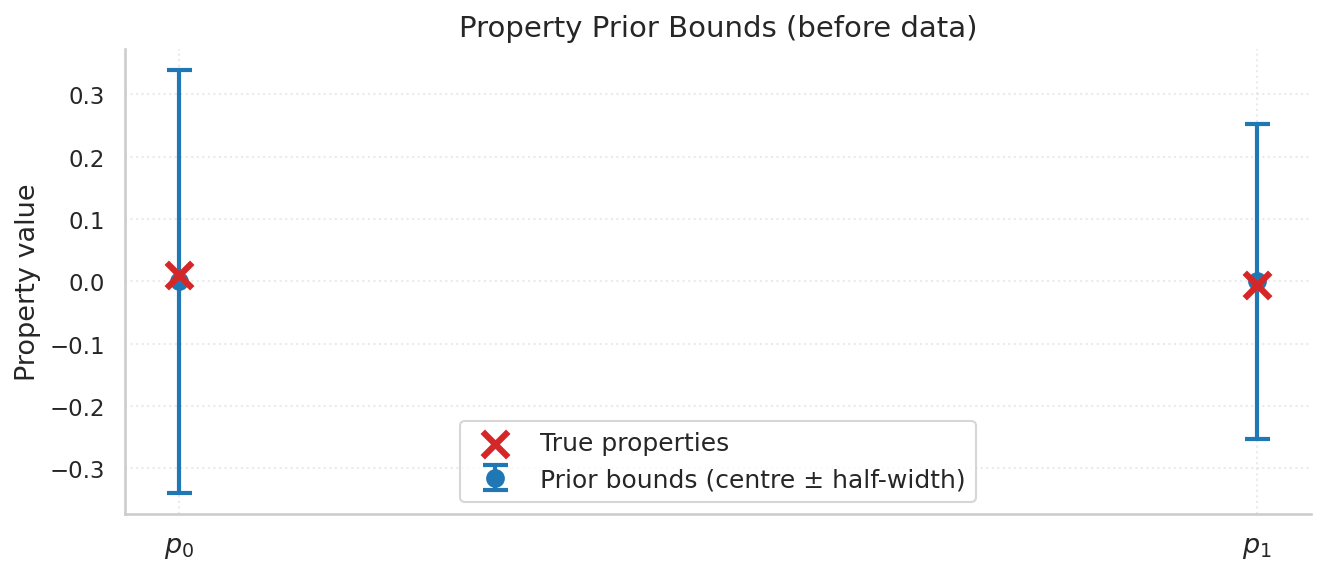

In [11]:
prior_qs    = [P.basis_vector(i) for i in range(P.dim)]
prior_upper = np.array([model_prior_support(T.adjoint(q)) for q in prior_qs])
prior_lower = np.array([
    -model_prior_support(M_model.multiply(-1.0, T.adjoint(q)))
    for q in prior_qs
])
prior_mid  = 0.5 * (prior_lower + prior_upper)
prior_half = 0.5 * (prior_upper - prior_lower)

print('Property prior bounds:')
for i in range(N_p):
    inside = prior_lower[i] <= true_props[i] <= prior_upper[i]
    print(f'  p_{i}: [{prior_lower[i]:.4f}, {prior_upper[i]:.4f}]  '
          f'true={true_props[i]:.4f}  inside={inside}')

plt.figure(figsize=(9, 4), dpi=150)
plt.errorbar(np.arange(N_p), prior_mid, yerr=prior_half, fmt='o',
             color='tab:blue', capsize=6, capthick=2, markersize=8, linewidth=2,
             label='Prior bounds (centre ± half-width)')
plt.scatter(np.arange(N_p), true_props, color='tab:red', marker='x', s=150,
            linewidths=3, zorder=10, label='True properties')
plt.xticks(np.arange(N_p), [f'$p_{i}$' for i in range(N_p)], fontsize=13)
plt.ylabel('Property value', fontsize=13)
plt.title('Property Prior Bounds (before data)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'prior_bounds.png'), dpi=200, bbox_inches='tight')
plt.show()


## DLI Solve

We minimise the dual master cost function over $\lambda \in D$ using the proximal bundle
method, solving for $\pm e_i$ directions to obtain upper and lower property bounds.

In [12]:
# Build cost oracle for direction q = P.basis_vector(0) (will be overridden per direction)
cost = DualMasterCostFunction(
    D, P, M_model,
    G, T,
    model_prior_support,
    data_error_support,
    d_tilde,
    P.basis_vector(0),
)

bundle_solver = ProximalBundleMethod(
    cost,
    rho0=1.0,
    rho_factor=2.0,
    tolerance=1e-4,
    max_iterations=300,
    bundle_size=30,
    qp_solver=OSQPQPSolver(),
)

basis_dirs     = [P.basis_vector(i) for i in range(P.dim)]
neg_basis_dirs = [P.multiply(-1.0, P.basis_vector(i)) for i in range(P.dim)]
lambda0        = D.zero

t0 = time.perf_counter()

upper_vals, _, upper_diag = solve_support_values(
    cost, basis_dirs, bundle_solver, lambda0, n_jobs=2
)
lower_neg_vals, _, lower_diag = solve_support_values(
    cost, neg_basis_dirs, bundle_solver, lambda0, n_jobs=2
)

elapsed = time.perf_counter() - t0

lower_vals = -lower_neg_vals
p_mid  = 0.5 * (lower_vals + upper_vals)
p_half = 0.5 * (upper_vals - lower_vals)

print(f'\nSolve time: {elapsed:.2f} s')
print('\nDLI property intervals:')
for i in range(N_p):
    inside = lower_vals[i] <= true_props[i] <= upper_vals[i]
    print(f'  p_{i}: [{lower_vals[i]:.5f}, {upper_vals[i]:.5f}]  '
          f'true={true_props[i]:.5f}  inside={inside}')

within = int(np.sum((true_props >= lower_vals) & (true_props <= upper_vals)))
total_iters = sum(d.num_iterations for d in upper_diag + lower_diag)
print(f'\nTrue properties captured : {within}/{N_p}')
print(f'Total bundle iterations  : {total_iters}')



Solve time: 3.37 s

DLI property intervals:
  p_0: [-0.33981, 0.33981]  true=0.01035  inside=True
  p_1: [-0.25330, 0.25330]  true=-0.00654  inside=True

True properties captured : 2/2
Total bundle iterations  : 38


## Results

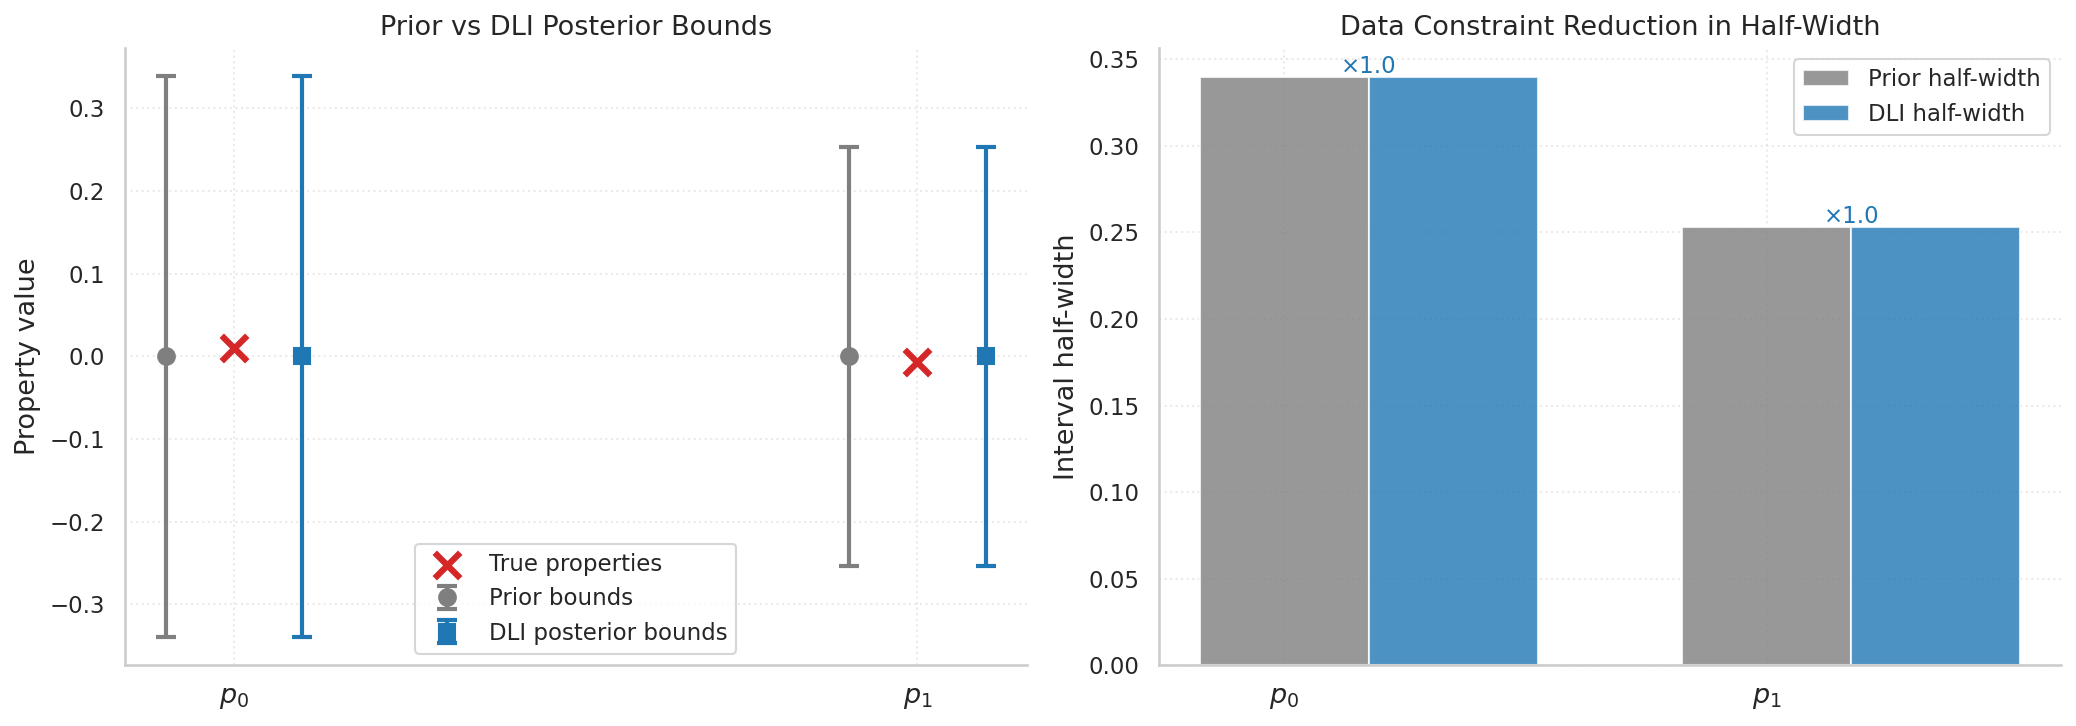


  RESULTS SUMMARY — Ellipsoid Prior
  Functional space dims    : 0, 0, 0, 0
  Total model dim          : 2  (σ₀/σ₁ only)
  Spectral helper count    : 10
  Noise-set level          : χ²(0.95, df=50)
  Noise radius             : 8.2161
  Prior dof_eff            : 42
  Prior ellipsoid radius   : 7.6239
  True properties captured : 2/2
  Mean posterior half-width: 0.29655
  Mean prior half-width    : 0.29655
  Mean reduction factor    : 1.00×
  Solve time               : 3.37 s


In [13]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

offsets = np.array([-0.1, 0.1])
axs[0].errorbar(np.arange(N_p) + offsets[0], prior_mid, yerr=prior_half,
                fmt='o', color='tab:gray', capsize=5, capthick=2, markersize=8,
                linewidth=2, label='Prior bounds')
axs[0].errorbar(np.arange(N_p) + offsets[1], p_mid, yerr=p_half,
                fmt='s', color='tab:blue', capsize=5, capthick=2, markersize=8,
                linewidth=2, label='DLI posterior bounds')
axs[0].scatter(np.arange(N_p), true_props, color='tab:red', marker='x',
               s=150, linewidths=3, zorder=10, label='True properties')
axs[0].set_xticks(np.arange(N_p))
axs[0].set_xticklabels([f'$p_{i}$' for i in range(N_p)], fontsize=13)
axs[0].set_ylabel('Property value', fontsize=13)
axs[0].set_title('Prior vs DLI Posterior Bounds', fontsize=13)
axs[0].legend(fontsize=11)
axs[0].grid(True, linestyle=':', alpha=0.4)

reduction = prior_half / np.maximum(p_half, 1e-12)
axs[1].bar(np.arange(N_p), prior_half, width=0.35, align='edge', color='tab:gray',
           alpha=0.8, label='Prior half-width')
axs[1].bar(np.arange(N_p) + 0.35, p_half, width=0.35, align='edge', color='tab:blue',
           alpha=0.8, label='DLI half-width')
for i in range(N_p):
    axs[1].text(i + 0.35, p_half[i] + 0.002,
                f'×{reduction[i]:.1f}', ha='center', fontsize=11, color='tab:blue')
axs[1].set_xticks([i + 0.175 for i in range(N_p)])
axs[1].set_xticklabels([f'$p_{i}$' for i in range(N_p)], fontsize=13)
axs[1].set_ylabel('Interval half-width', fontsize=13)
axs[1].set_title('Data Constraint Reduction in Half-Width', fontsize=13)
axs[1].legend(fontsize=11)
axs[1].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'dli_results.png'), dpi=200, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('  RESULTS SUMMARY — Ellipsoid Prior')
print('='*60)
print(f'  Functional space dims    : {M_vp.dim}, {M_vs_IC.dim}, {M_vs_M.dim}, {M_rho.dim}')
print(f'  Total model dim          : {M_model.dim}  (σ₀/σ₁ only)')
print(f'  Spectral helper count    : {N}')
print(f'  Noise-set level          : χ²(0.95, df={N_d})')
print(f'  Noise radius             : {chi2_radius:.4f}')
print(f'  Prior dof_eff            : {dof_eff}')
print(f'  Prior ellipsoid radius   : {chi2_model_radius:.4f}')
print(f'  True properties captured : {within}/{N_p}')
print(f'  Mean posterior half-width: {np.mean(p_half):.5f}')
print(f'  Mean prior half-width    : {np.mean(prior_half):.5f}')
print(f'  Mean reduction factor    : {np.mean(reduction):.2f}×')
print(f'  Solve time               : {elapsed:.2f} s')
print('='*60)
